# Leakage model analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

leaky = pd.read_csv("Results/LEAKY_FIXED.csv")
loro = pd.read_csv("Results/SEGMENTS_FIXED.csv")

In [18]:
metrics = [
    "roc_auc",
    "ap",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1"
]

leaky[metrics].agg(["mean", "std"])

,roc_auc,ap,seg_sensitivity,seg_precision,seg_f1
mean,0.966022,0.698315,0.665854,0.661692,0.645084
std,0.038071,0.207655,0.213299,0.184850,0.194988


In [19]:
loro[metrics].agg(["mean", "std"])

,roc_auc,ap,seg_sensitivity,seg_precision,seg_f1
mean,0.889736,0.416556,0.415306,0.42094,0.433214
std,0.137016,0.303695,0.297176,0.31852,0.238779


In [20]:
metrics = [
    "roc_auc",
    "ap",
    "seg_sensitivity",
    "seg_specificity",
    "seg_precision",
    "seg_f1",
]

# Mean over the 5 leaky folds for each patient
leaky_patient = leaky.groupby("patient")[metrics].mean()

# Mean over held-out records for each patient
loro_patient = loro.groupby("patient")[metrics].mean()

In [21]:
compare = leaky_patient.join(
    loro_patient,
    lsuffix="_leaky",
    rsuffix="_loro"
)

In [23]:
import pandas as pd

rows = []

labels = {
    "roc_auc": "ROC-AUC",
    "ap": "Average Precision",
    "seg_sensitivity": "Sensitivity",
    "seg_specificity": "Specificity",
    "seg_precision": "Precision",
    "seg_f1": "F1-score",
}

for m in metrics:
    leaky_mean = compare[f"{m}_leaky"].mean()
    loro_mean = compare[f"{m}_loro"].mean()

    abs_diff = leaky_mean - loro_mean
    rel_diff = abs_diff / loro_mean * 100

    higher = (
        compare[f"{m}_leaky"] >
        compare[f"{m}_loro"]
    ).sum()

    rows.append({
        "Metric": labels[m],
        "Random-window CV (Exp. 1)": leaky_mean,
        "LORO CV (Exp. 2)": loro_mean,
        "Absolute difference": abs_diff,
        "Relative difference (%)": rel_diff,
        "Patients higher under Exp. 1": f"{higher}/{len(compare)}"
    })

summary = pd.DataFrame(rows)

summary.iloc[:,1:5] = summary.iloc[:,1:5].round(3)
summary["Relative difference (%)"] = (
    summary["Relative difference (%)"]
    .round(1)
    .astype(str) + "%"
)

summary

,Metric,Random-window CV (Exp. 1),LORO CV (Exp. 2),Absolute difference,Relative difference (%),Patients higher under Exp. 1
0,ROC-AUC,0.966,0.895,0.071,7.9%,24/24
1,Average Precision,0.698,0.431,0.267,62.0%,24/24
2,Sensitivity,0.666,0.438,0.228,52.0%,24/24
3,Specificity,0.993,0.985,0.008,0.8%,21/24
4,Precision,0.662,0.423,0.239,56.5%,23/24
5,F1-score,0.645,0.402,0.243,60.3%,24/24


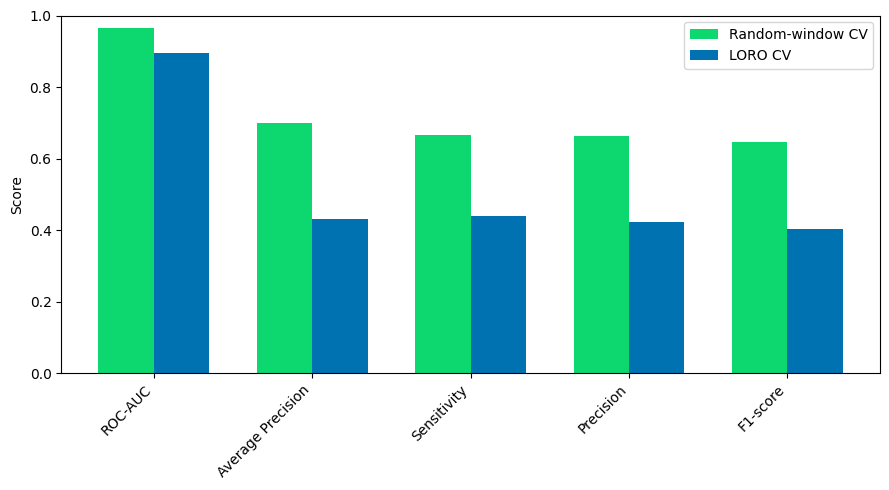

In [30]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "ROC-AUC",
    "Average Precision",
    "Sensitivity",
    "Precision",
    "F1-score"
]

leaky_values = summary.loc[
    summary["Metric"].isin(metrics),
    "Random-window CV (Exp. 1)"
].values

loro_values = summary.loc[
    summary["Metric"].isin(metrics),
    "LORO CV (Exp. 2)"
].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))


ax.bar(
    x - width/2,
    leaky_values,
    width,
    label="Random-window CV",
    color="#0DD76F"   # orange/red
)

ax.bar(
    x + width/2,
    loro_values,
    width,
    label="LORO CV",
    color="#0072B2"   # blue
)

ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

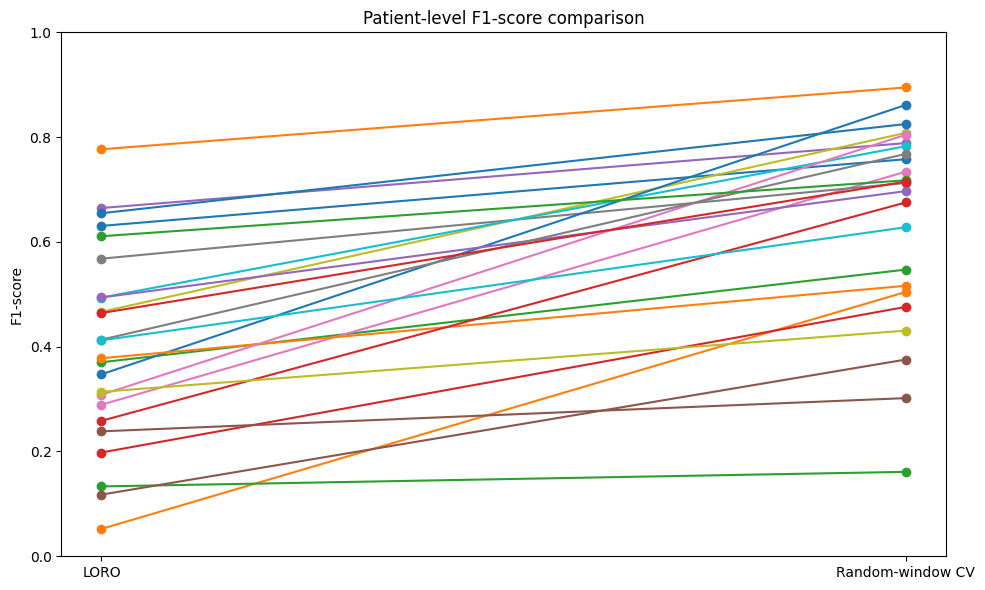

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ensure same patient order
patients = sorted(
    set(leaky_patient.index)
    .intersection(loro_patient.index)
)

leaky_f1 = leaky_patient.loc[patients, "seg_f1"]
loro_f1 = loro_patient.loc[patients, "seg_f1"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, patient in enumerate(patients):
    # LORO left (x=0), Random-window right (x=1)
    ax.plot(
        [0, 1],
        [loro_f1[patient], leaky_f1[patient]],
        marker="o"
    )


ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["LORO", "Random-window CV"]
)

ax.set_ylabel("F1-score")
ax.set_ylim(0, 1)

ax.set_title(
    "Patient-level F1-score comparison"
)

plt.tight_layout()
plt.show()